# Car Damage Detection — YOLO26s-seg + VLM Technician Report

**Pipeline:** detect & segment damage (YOLO26s-seg, weights loaded from Google Drive) →
compute a rough heuristic cost estimate → hand the detections + annotated photo to a
vision-language model (Gemini) acting as an Egyptian car-repair technician, which
returns a full report: damage description, repair steps, tools/equipment needed,
time estimate, and cost — all in **Egyptian Pounds (EGP)**.

Run every cell top to bottom, in order — each section only depends on cells above it.
Model weights are loaded directly from your Drive backup, so **no dataset download is
needed just to run Sections 1–6a**. Section 6b (testing on real CarDD dataset images)
does need the dataset, so it downloads and converts it inline before running the test.

If you ever want to retrain from scratch, see the **Appendix** at the very bottom —
it's separate so it doesn't clutter or accidentally run during normal use.


## 1. Install dependencies

In [ ]:
!pip uninstall -y pillow
!rm -rf /usr/local/lib/python3.13/dist-packages/PIL
!pip install --no-cache-dir pillow


!pip install -q --no-cache-dir ultralytics opencv-python-headless google-genai gdown pycocotools

Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.3 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 263.5 MB/s eta 0:00:00


## 2. Configuration

The only cell you should need to edit.

In [ ]:
import os

# ---------------- MODEL (loaded from Drive backup) ----------------
# YOLO26s-seg (Ultralytics' newer, more accurate architecture) -- update this path
# to wherever you uploaded the new best.pt from your Drive folder.
TRAINED_WEIGHTS_PATH = "/content/drive/MyDrive/car_damage_backup/yolo 8 25 epoch/best.pt"
# ---------------- SEVERITY HEURISTIC ----------------
# % of the image covered by a damage mask -> severity bucket.
# Placeholder until you train a real classifier on labeled severity crops.
SEVERITY_THRESHOLDS = {"minor": 0.5, "moderate": 2.0}  # <0.5% minor, 0.5-2% moderate, >2% severe

# ---------------- VLM TECHNICIAN REPORT ----------------
GEMINI_API_KEY = "AQ.Ab8RN6LPGj3MAu8uAX--HNOF23KOusEsV1UlrrKhBPw6oHAmWw"    # <<< PUT YOUR GEMINI API KEY HERE
GEMINI_MODEL_NAME = "gemini-3.5-flash"

# ---------------- JUDGE MODEL (independently reviews the technician report) ----------------
JUDGE_MODEL_NAME = "gemini-3.5-flash-lite"

# ---------------- TEST IMAGE ----------------
TEST_IMAGE_PATH = None   # set a path, or leave None and use the "upload images" cell in Section 5


## 3. Load the model and run detection + segmentation + cost estimate

In [ ]:
import cv2
import json
from google.colab import drive
from ultralytics import YOLO

drive.mount('/content/drive')
yolo = YOLO(TRAINED_WEIGHTS_PATH)

# Rough panel-repair cost table (USD) -- a fallback signal only; the VLM step in
# Section 4 produces the real, EGP-priced estimate.
COST_TABLE = {
    "dent":          {"minor": 80,  "moderate": 220, "severe": 500},
    "scratch":       {"minor": 50,  "moderate": 150, "severe": 350},
    "crack":         {"minor": 100, "moderate": 300, "severe": 700},
    "glass_shatter": {"minor": 200, "moderate": 400, "severe": 800},
    "lamp_broken":   {"minor": 90,  "moderate": 180, "severe": 300},
    "tire_flat":     {"minor": 60,  "moderate": 120, "severe": 250},
}


def normalize_class_name(name):
    return name.strip().lower().replace(" ", "_")


def severity_from_area_pct(area_pct):
    if area_pct < SEVERITY_THRESHOLDS["minor"]:
        return "minor"
    if area_pct < SEVERITY_THRESHOLDS["moderate"]:
        return "moderate"
    return "severe"


def run_pipeline(image_path, conf=0.35, save_annotated=True):
    """Detect + segment damage, estimate severity/cost, and (optionally) save an
    annotated copy of the image with each damage region highlighted."""
    image = cv2.imread(image_path)
    height, width = image.shape[:2]
    results = yolo.predict(image_path, conf=conf, verbose=False)[0]

    findings = []
    annotated = image.copy()

    if results.masks is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        class_indices = results.boxes.cls.cpu().numpy()
        masks = results.masks.data.cpu().numpy()  # (N, mask_h, mask_w)

        for box, class_idx, mask in zip(boxes, class_indices, masks):
            class_name = normalize_class_name(yolo.names[int(class_idx)])
            mask_full = cv2.resize(mask, (width, height))
            area_pct = round(100 * float(mask_full.sum()) / (width * height), 3)
            severity = severity_from_area_pct(area_pct)
            cost = COST_TABLE.get(class_name, {}).get(severity)

            findings.append({
                "damage_type": class_name,
                "severity": severity,
                "bbox": [int(v) for v in box],
                "area_pct_of_image": area_pct,
                "estimated_repair_cost_usd": cost,
            })

            if save_annotated:
                color = (0, 0, 255)
                overlay = annotated.copy()
                overlay[mask_full > 0.5] = color
                annotated = cv2.addWeighted(overlay, 0.4, annotated, 0.6, 0)
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                cv2.putText(annotated, f"{class_name} ({severity})", (x1, max(y1 - 8, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    report = {
        "image": image_path,
        "num_findings": len(findings),
        "findings": findings,
        "total_estimated_cost_usd": sum(f["estimated_repair_cost_usd"] or 0 for f in findings),
    }

    if save_annotated:
        annotated_path = os.path.splitext(image_path)[0] + "_annotated.jpg"
        cv2.imwrite(annotated_path, annotated)
        report["annotated_image"] = annotated_path

    return report


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Mounted at /content/drive


## 4. VLM technician report (Gemini, grounded with the detections)

Section 3 gives us the raw detections: damage **type/label**, **bounding box**,
**segmentation-mask area %**, and a heuristic **severity**, plus an annotated image
with the detected regions highlighted. We hand all of that to a vision-language
model acting as **an experienced car repair technician in Egypt**.

It's grounded with the exact labels + segmentation info the detector already found,
so it isn't guessing *what* or *where* the damage is — it only reasons about the
technician-level details: repair steps, tools/equipment, time, and cost, all in EGP.


In [ ]:
import time
import random
from google import genai
from google.genai import types as genai_types
from PIL import Image

gemini_client = genai.Client(api_key=GEMINI_API_KEY)

VLM_TECHNICIAN_PROMPT_TEMPLATE = (
    "You are an experienced car repair technician working in Egypt. "
    "A computer-vision pipeline (YOLO26-seg) has already detected and localized "
    "the damage on this vehicle. The attached photo is annotated with the detected "
    "region(s) highlighted, and the JSON below lists exactly what the detector found "
    "-- damage type/label, severity, bounding box, and the percentage of the image "
    "each damaged area covers (derived from its segmentation mask):\n\n"
    "{findings_json}\n\n"
    "Treat this JSON as ground truth for WHICH damages exist, WHERE they are, and "
    "their type/severity/size -- do not invent additional damage it doesn't mention, "
    "and do not dismiss damage it does mention. Look closely at the highlighted "
    "region(s) in the photo and write a full technician's report.\n\n"
    "Respond with ONLY a JSON object (no markdown fences, no extra commentary) "
    "matching this exact shape:\n"
    "{{\n"
    '  "damage_assessment": [\n'
    "    {{\n"
    '      "damage_type": string,\n'
    '      "location_on_vehicle": string,\n'
    '      "severity": "minor" | "moderate" | "severe",\n'
    '      "description": string\n'
    "    }}\n"
    "  ],\n"
    '  "repair_steps": [string, ...],\n'
    '  "tools_and_equipment_needed": [string, ...],\n'
    '  "estimated_repair_time_hours": number,\n'
    '  "technician_service_cost_egp": number,\n'
    '  "equipment_and_parts_cost_egp": number,\n'
    '  "total_estimated_cost_egp": number,\n'
    '  "notes": string\n'
    "}}\n\n"
    "All monetary values MUST be realistic current Egyptian market prices, given as "
    "plain numbers in Egyptian Pounds (EGP) -- do not use USD or any other currency, "
    "and do not include currency symbols or the word 'EGP' inside the numbers. "
    "estimated_repair_time_hours must be a plain number of hours (decimals allowed, "
    "e.g. 1.5)."
)

# Errors worth retrying -- transient/server-side, not our fault
RETRYABLE_STATUS_CODES = {429, 500, 502, 503, 504}
MAX_RETRIES = 5
BASE_DELAY_SECONDS = 2  # doubles each retry: 2, 4, 8, 16, 32...


def _is_retryable(exception):
    """Best-effort check: does this look like a transient error worth retrying?"""
    msg = str(exception)
    if any(str(code) in msg for code in RETRYABLE_STATUS_CODES):
        return True
    status = getattr(exception, "status", None) or getattr(exception, "code", None)
    return status in RETRYABLE_STATUS_CODES


def get_vlm_technician_report(image_path, findings):
    """Send the (annotated) image + CV findings to the VLM and get back a full
    technician-style repair report, priced in EGP.

    Retries transient errors (503 overloaded, 429 rate-limited, etc.) with
    exponential backoff + jitter. Returns a dict parsed from the VLM's JSON
    response. On final failure (blocked response, malformed JSON, or the API
    still erroring after all retries) it returns a dict with an 'error' key
    and the raw text (if any) under 'raw_response', so a bad call never
    crashes the whole pipeline.
    """
    image = Image.open(image_path)
    prompt = VLM_TECHNICIAN_PROMPT_TEMPLATE.format(findings_json=json.dumps(findings, indent=2))

    last_error = None
    for attempt in range(MAX_RETRIES):
        try:
            response = gemini_client.models.generate_content(
                model=GEMINI_MODEL_NAME,
                contents=[prompt, image],
                config=genai_types.GenerateContentConfig(
                    response_mime_type="application/json",
                    temperature=0.2,
                ),
            )
            break  # success, exit retry loop
        except Exception as e:
            last_error = e
            if _is_retryable(e) and attempt < MAX_RETRIES - 1:
                delay = BASE_DELAY_SECONDS * (2 ** attempt) + random.uniform(0, 1)
                print(f"  [retry] VLM call failed ({e}); retrying in {delay:.1f}s "
                      f"(attempt {attempt + 1}/{MAX_RETRIES})...")
                time.sleep(delay)
                continue
            else:
                return {"error": f"VLM API call failed: {e}", "raw_response": None}
    else:
        return {"error": f"VLM API call failed after {MAX_RETRIES} retries: {last_error}", "raw_response": None}

    if not getattr(response, "candidates", None):
        return {"error": "VLM returned no candidates (likely blocked by safety filters).", "raw_response": None}

    try:
        return json.loads(response.text)
    except (json.JSONDecodeError, TypeError) as e:
        return {"error": f"Could not parse VLM JSON response: {e}", "raw_response": response.text}


def run_pipeline_with_report(image_path, conf=0.35):
    """Run detection + segmentation (Section 3), then send the findings + annotated
    image to the VLM for a full EGP-priced technician report."""
    report = run_pipeline(image_path, conf=conf, save_annotated=True)
    vlm_image_path = report.get("annotated_image", image_path)
    report["vlm_technician_report"] = get_vlm_technician_report(vlm_image_path, report["findings"])
    return report

## 5. Judge the technician report (gemini pro)

A second, independent model reviews the first model's output — this matters
because a model grading its own answer tends to be overly generous (self-preference
bias). GPT-4o gets the same photo, the raw CV findings, and Gemini's technician
report, and independently checks:

1. Does the damage description actually match the photo + detections?
2. Are the repair steps and tools appropriate for the stated damage?
3. Are the EGP prices realistic for the Egyptian market?
4. Is the time estimate reasonable?

It returns a structured verdict (`approved` / `needs_revision`, a 0–10 score, and
any issues found) rather than just a thumbs up/down.


In [ ]:


JUDGE_MODEL_NAME = "gemini-3.5-flash-lite"

JUDGE_PROMPT_TEMPLATE = (
    "You are an independent quality-assurance auditor reviewing a car repair "
    "estimate. You will be shown a photo of vehicle damage, the raw detections "
    "from a computer-vision pipeline (damage type, severity, location, size), and "
    "a technician's report that another AI model produced from that photo + those "
    "detections. Your job is to independently judge whether the technician's "
    "report is accurate and realistic -- do not simply trust it.\n\n"
    "CV detections:\n{findings_json}\n\n"
    "Technician's report to review:\n{vlm_report_json}\n\n"
    "Look closely at the photo yourself and check:\n"
    "1. Does the damage_assessment actually match what you see in the photo and "
    "the CV detections (no invented damage, nothing missed)?\n"
    "2. Are the repair_steps and tools_and_equipment_needed appropriate and "
    "sufficient for the stated damage type/severity?\n"
    "3. Are the EGP prices realistic for the current Egyptian car-repair market "
    "-- not too high, not suspiciously low?\n"
    "4. Is estimated_repair_time_hours reasonable for the described work?\n\n"
    "Respond with ONLY a JSON object (no markdown fences, no extra commentary) "
    "matching this exact shape:\n"
    "{{\n"
    '  "verdict": "approved" | "needs_revision",\n'
    '  "damage_description_accurate": true | false,\n'
    '  "repair_plan_appropriate": true | false,\n'
    '  "pricing_realistic": true | false,\n'
    '  "time_estimate_reasonable": true | false,\n'
    '  "issues_found": [string, ...],\n'
    '  "suggested_corrections": string,\n'
    '  "overall_score_out_of_10": number\n'
    "}}"
)


def get_judge_verdict(image_path, findings, vlm_report):
    """Send the image + CV findings + the first model's technician report to a
    second Gemini model (JUDGE_MODEL_NAME) for an independent quality review."""
    image = Image.open(image_path)
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        findings_json=json.dumps(findings, indent=2),
        vlm_report_json=json.dumps(vlm_report, indent=2),
    )

    try:
        response = gemini_client.models.generate_content(
            model=JUDGE_MODEL_NAME,
            contents=[prompt, image],
            config=genai_types.GenerateContentConfig(
                response_mime_type="application/json",
                temperature=0.2,
            ),
        )
    except Exception as e:
        return {"error": f"Judge API call failed: {e}", "raw_response": None}

    if not getattr(response, "candidates", None):
        return {"error": "Judge returned no candidates (likely blocked by safety filters).", "raw_response": None}

    try:
        return json.loads(response.text)
    except (json.JSONDecodeError, TypeError) as e:
        return {"error": f"Could not parse judge JSON response: {e}", "raw_response": response.text}


def run_pipeline_with_review(image_path, conf=0.35):
    """Run detection + segmentation + the Gemini technician report (Section 4),
    then send everything to a second Gemini model for an independent judged review."""
    report = run_pipeline_with_report(image_path, conf=conf)
    vlm_image_path = report.get("annotated_image", image_path)
    report["judge_verdict"] = get_judge_verdict(vlm_image_path, report["findings"], report["vlm_technician_report"])
    return report

## 6. Run it

- **6a** — a single image (path set in Section 2)
- **6b** — real sample images from the CarDD dataset (downloads/converts it first)
- **6c** — your own uploaded photos


### 6a. On a single image (path set in Section 2)


In [ ]:
from IPython.display import Image as IPImage, display

if TEST_IMAGE_PATH is None:
    raise ValueError(
        "TEST_IMAGE_PATH is None. Either set it in Section 2, or skip this cell and "
        "use the 'upload your own images' cell below instead."
    )

report = run_pipeline_with_review(TEST_IMAGE_PATH)

print("=== Raw CV detections ===")
print(json.dumps(report["findings"], indent=2))

print("\n=== VLM technician report (EGP) ===")
print(json.dumps(report["vlm_technician_report"], indent=2))

print("\n=== Judge verdict (pro) ===")
print(json.dumps(report["judge_verdict"], indent=2))

display(IPImage(filename=report["annotated_image"]))


### 6b. On dataset images (from CarDD itself, not uploads)

Pulls real sample images straight from the CarDD dataset and runs the full pipeline
on them. This needs the dataset downloaded and converted to YOLO format first —
the cells below do that once, then the test loop at the end of this section runs on it.


**Dataset configuration**


In [ ]:
CARDD_DRIVE_FILE_ID = "1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx"   # from your Google Drive share link
CARDD_ZIP_PATH = "/content/CarDD_release.zip"
CARDD_EXTRACT_DIR = "/content/CarDD_release"
YOLO_DATASET_DIR = "/content/CarDD_yolo"                    # converted YOLO-seg dataset lands here

EPOCHS = 50          # <<< bump to 100-150 for real accuracy
IMG_SIZE = 640
BATCH_SIZE = 8
DEVICE = 0            # Colab GPU index; use "cpu" if you didn't enable a GPU runtime


**Download the CarDD dataset from Google Drive**


In [ ]:
drive.mount('/content/drive')  # already mounted in Section 3, safe to re-call
CARDD_ZIP_PATH = "/content/drive/MyDrive/car_damage_backup/the data set/CarDD_release.zip"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**If the cell above fails or downloads a tiny HTML file instead of the real zip** —
Google's virus-scan warning is blocking `gdown` on this large file. Fallback: download
`CarDD_release.zip` manually from the link in your browser, upload it to your own
Google Drive, then uncomment and run this instead:

In [ ]:
# drive.mount('/content/drive')  # already mounted in Section 3, safe to re-call
# CARDD_ZIP_PATH = "/content/drive/MyDrive/CarDD_release.zip"  # <<< adjust to wherever you put it


In [ ]:
import zipfile

assert os.path.getsize(CARDD_ZIP_PATH) > 10_000_000, (
    "Downloaded file looks too small to be the real dataset -- gdown probably got a Google Drive "
    "warning page instead of the zip. Use the manual-download fallback above."
)

if not os.path.exists(CARDD_EXTRACT_DIR):
    with zipfile.ZipFile(CARDD_ZIP_PATH, "r") as z:
        z.extractall("/content")
    print("Extracted.")
else:
    print("Already extracted.")


Extracted.


**Locate the COCO annotation files**

CarDD's official release ships COCO-format annotations
(`instances_train2017.json`, etc.) under a `CarDD_COCO/annotations/` folder, with
images in sibling `train2017/ val2017/ test2017/` folders. Layouts inside the zip
occasionally shift between releases, so this cell searches for the actual paths
rather than assuming.


In [ ]:
import glob

coco_jsons = sorted(glob.glob(f"{CARDD_EXTRACT_DIR}/**/*.json", recursive=True))
print("Found annotation files:")
for path in coco_jsons:
    print(" ", path)

TRAIN_JSON = next((p for p in coco_jsons if "train" in p.lower()), None)
VAL_JSON   = next((p for p in coco_jsons if "val" in p.lower()), None)
TEST_JSON  = next((p for p in coco_jsons if "test" in p.lower()), None)

print("\nUsing:\n train:", TRAIN_JSON, "\n val:", VAL_JSON, "\n test:", TEST_JSON)
assert TRAIN_JSON and VAL_JSON, (
    "Couldn't auto-find train/val annotation JSONs -- open the printed list above and set "
    "TRAIN_JSON / VAL_JSON manually to the right paths."
)


Found annotation files:
  /content/CarDD_release/CarDD_COCO/annotations/instances_test2017.json
  /content/CarDD_release/CarDD_COCO/annotations/instances_train2017.json
  /content/CarDD_release/CarDD_COCO/annotations/instances_val2017.json

Using:
 train: /content/CarDD_release/CarDD_COCO/annotations/instances_train2017.json 
 val: /content/CarDD_release/CarDD_COCO/annotations/instances_val2017.json 
 test: /content/CarDD_release/CarDD_COCO/annotations/instances_test2017.json


**Convert COCO annotations to YOLO segmentation format**

Ultralytics trains segmentation models from `.txt` label files (one polygon per
line, normalized 0-1), not COCO JSON, so we convert. Handles both polygon-style
and RLE-style COCO segmentations. Note: if an instance has multiple disjoint
polygons (e.g. a scratch split by an occluding part), each polygon is written as
a separate line with the same class — a minor simplification that's fine for a
prototype.


In [ ]:
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils
import cv2
import numpy as np
import shutil


def coco_segmentation_to_yolo_polygons(segmentation, img_w, img_h):
    """Convert one COCO annotation's segmentation (polygon or RLE) into a list of
    normalized (0-1) YOLO-seg polygons."""
    if isinstance(segmentation, list):
        polygons = segmentation
    else:
        rle = (mask_utils.frPyObjects(segmentation, img_h, img_w)
               if isinstance(segmentation.get("counts"), list) else segmentation)
        binary_mask = mask_utils.decode(rle)
        contours, _ = cv2.findContours(binary_mask.astype(np.uint8), cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)
        polygons = [c.flatten().tolist() for c in contours if len(c) >= 6]

    normalized_polygons = []
    for polygon in polygons:
        if len(polygon) < 6:
            continue
        normalized = []
        for i in range(0, len(polygon), 2):
            normalized += [polygon[i] / img_w, polygon[i + 1] / img_h]
        normalized_polygons.append(normalized)
    return normalized_polygons


def guess_images_dir(json_path):
    """CarDD image folders sit next to (or a couple levels from) the annotation JSON;
    try the common candidates for whichever split this JSON belongs to."""
    base_dir = os.path.dirname(os.path.dirname(json_path))
    lower_path = json_path.lower()
    if "train" in lower_path:
        split_folder = "train2017"
    elif "test" in lower_path:
        split_folder = "test2017"
    else:
        split_folder = "val2017"

    for candidate in [os.path.join(base_dir, split_folder),
                       os.path.join(os.path.dirname(json_path), split_folder)]:
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError(f"Could not locate an images folder for {json_path}")


def convert_coco_split_to_yolo(json_path, split_name):
    coco = COCO(json_path)
    images_dir = guess_images_dir(json_path)

    out_images_dir = f"{YOLO_DATASET_DIR}/images/{split_name}"
    out_labels_dir = f"{YOLO_DATASET_DIR}/labels/{split_name}"
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_labels_dir, exist_ok=True)

    for image_id in coco.getImgIds():
        image_info = coco.loadImgs(image_id)[0]
        src_image_path = os.path.join(images_dir, image_info["file_name"])
        if not os.path.exists(src_image_path):
            continue
        shutil.copy(src_image_path, os.path.join(out_images_dir, image_info["file_name"]))

        annotation_ids = coco.getAnnIds(imgIds=image_id)
        lines = []
        for annotation in coco.loadAnns(annotation_ids):
            class_id = annotation["category_id"] - 1  # COCO category ids are 1-indexed
            for polygon in coco_segmentation_to_yolo_polygons(
                annotation["segmentation"], image_info["width"], image_info["height"]
            ):
                lines.append(f"{class_id} " + " ".join(f"{v:.6f}" for v in polygon))

        label_filename = os.path.splitext(image_info["file_name"])[0] + ".txt"
        with open(os.path.join(out_labels_dir, label_filename), "w") as f:
            f.write("\n".join(lines))

    return len(coco.getImgIds())


class_names = [cat["name"] for cat in COCO(TRAIN_JSON).loadCats(COCO(TRAIN_JSON).getCatIds())]

num_train = convert_coco_split_to_yolo(TRAIN_JSON, "train")
num_val = convert_coco_split_to_yolo(VAL_JSON, "val")

# The paper's Table IV/V numbers are computed on CarDD's held-out TEST set (374 images),
# not the val set -- convert it too if the release includes test annotations, so Section
# A8 below can validate on the same split the paper used.
num_test = convert_coco_split_to_yolo(TEST_JSON, "test") if TEST_JSON else 0

print(f"Converted {num_train} train / {num_val} val / {num_test} test images. Classes: {class_names}")
if not TEST_JSON:
    print("\nNo test-set annotation JSON was found -- Section A8's validation will run on "
          "the val split instead, which won't exactly match the paper's reported numbers.")


loading annotations into memory...
Done (t=0.40s)
creating index...
index created!
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Converted 2816 train / 810 val / 374 test images. Classes: ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']


In [ ]:
yaml_content = f"path: {YOLO_DATASET_DIR}\ntrain: images/train\nval: images/val\n"
if num_test > 0:
    yaml_content += "test: images/test\n"
yaml_content += "names:\n"
for i, name in enumerate(class_names):
    yaml_content += f"  {i}: {name}\n"

with open(f"{YOLO_DATASET_DIR}/data.yaml", "w") as f:
    f.write(yaml_content)
print(yaml_content)


path: /content/CarDD_yolo
train: images/train
val: images/val
test: images/test
names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



**Run the test loop**

Uses the dataset downloaded/converted just above. Prefers the `test` split, falls
back to `val`, then `train`, depending on whichever splits got converted.


Using the 'test' split (374 images available)

/content/CarDD_yolo/images/test/003301.jpg
--- Raw CV detections ---
[
  {
    "damage_type": "glass_shatter",
    "severity": "severe",
    "bbox": [
      34,
      88,
      875,
      746
    ],
    "area_pct_of_image": 43.927,
    "estimated_repair_cost_usd": 800
  }
]


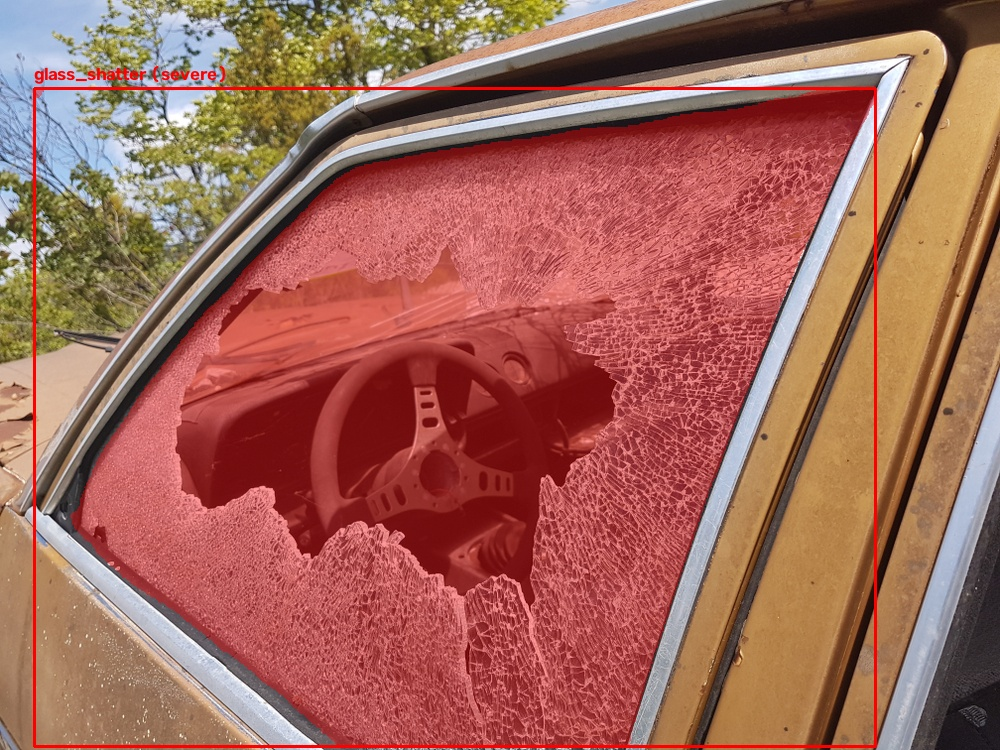


/content/CarDD_yolo/images/test/003011.jpg
--- Raw CV detections ---
[
  {
    "damage_type": "scratch",
    "severity": "severe",
    "bbox": [
      686,
      351,
      928,
      563
    ],
    "area_pct_of_image": 2.987,
    "estimated_repair_cost_usd": 350
  },
  {
    "damage_type": "dent",
    "severity": "severe",
    "bbox": [
      584,
      161,
      895,
      315
    ],
    "area_pct_of_image": 4.262,
    "estimated_repair_cost_usd": 500
  }
]


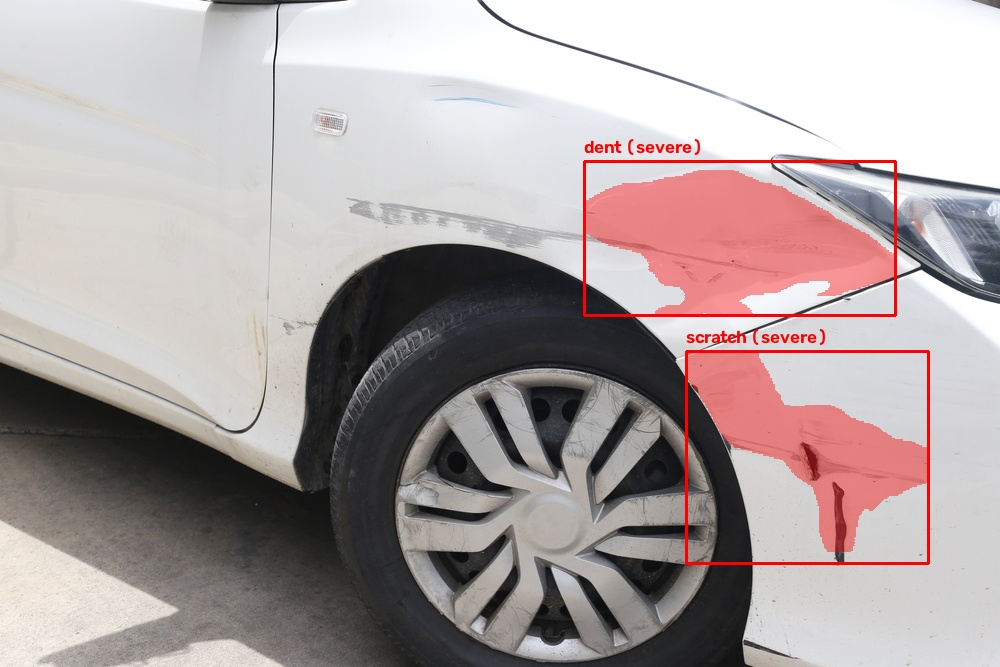


/content/CarDD_yolo/images/test/001502.jpg
--- Raw CV detections ---
[
  {
    "damage_type": "scratch",
    "severity": "moderate",
    "bbox": [
      322,
      579,
      483,
      655
    ],
    "area_pct_of_image": 1.443,
    "estimated_repair_cost_usd": 150
  },
  {
    "damage_type": "dent",
    "severity": "severe",
    "bbox": [
      348,
      334,
      616,
      494
    ],
    "area_pct_of_image": 5.148,
    "estimated_repair_cost_usd": 500
  },
  {
    "damage_type": "lamp_broken",
    "severity": "severe",
    "bbox": [
      152,
      16,
      763,
      357
    ],
    "area_pct_of_image": 19.795,
    "estimated_repair_cost_usd": 300
  },
  {
    "damage_type": "dent",
    "severity": "severe",
    "bbox": [
      615,
      49,
      997,
      492
    ],
    "area_pct_of_image": 14.151,
    "estimated_repair_cost_usd": 500
  }
]


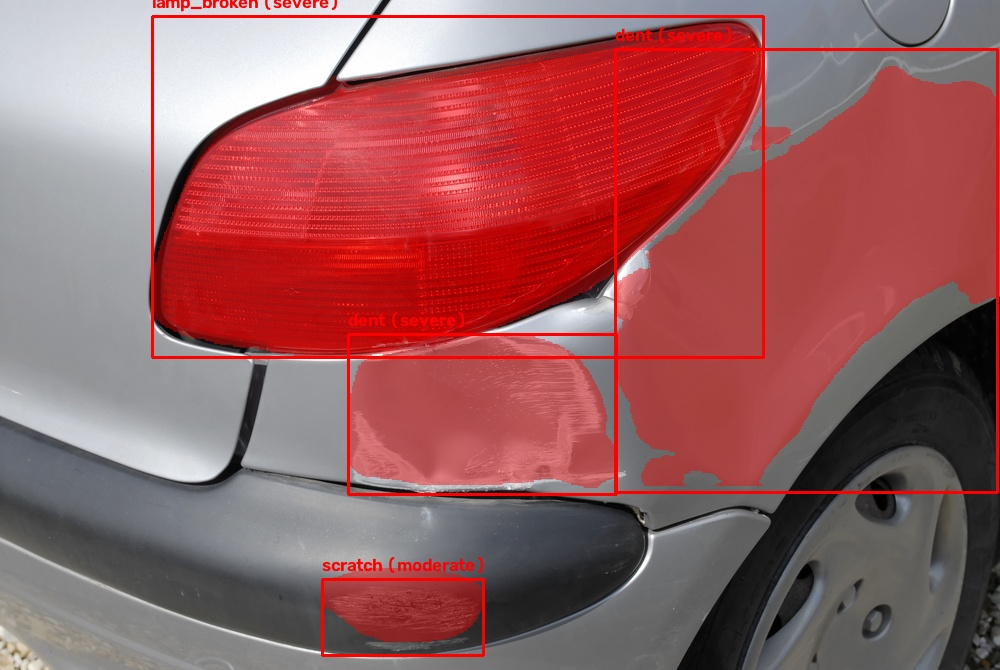


/content/CarDD_yolo/images/test/003956.jpg
--- Raw CV detections ---
[
  {
    "damage_type": "scratch",
    "severity": "severe",
    "bbox": [
      304,
      144,
      619,
      423
    ],
    "area_pct_of_image": 5.91,
    "estimated_repair_cost_usd": 350
  },
  {
    "damage_type": "dent",
    "severity": "severe",
    "bbox": [
      753,
      220,
      957,
      451
    ],
    "area_pct_of_image": 3.792,
    "estimated_repair_cost_usd": 500
  }
]


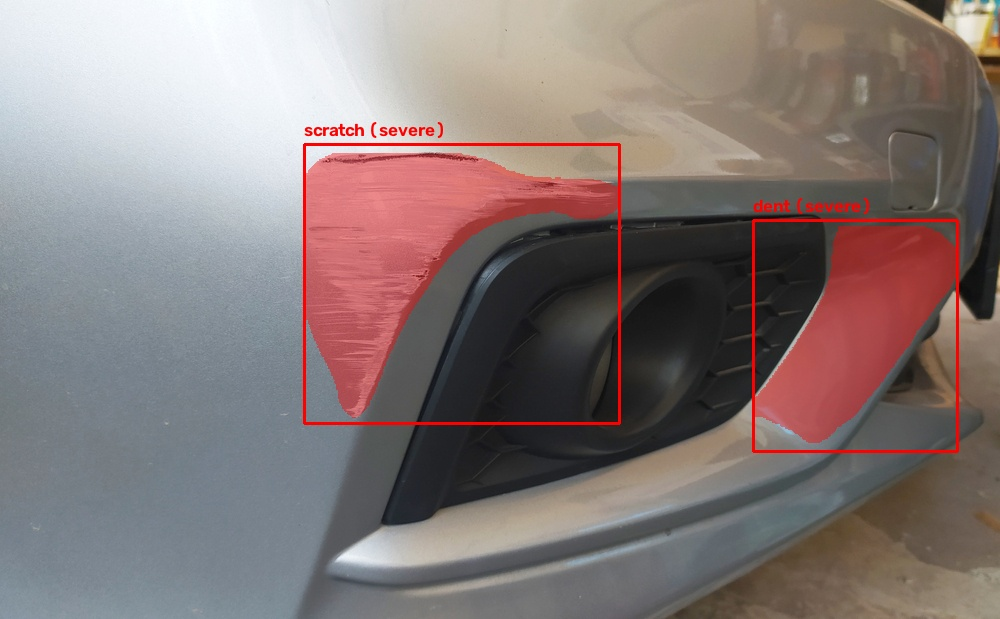


/content/CarDD_yolo/images/test/002922.jpg
--- Raw CV detections ---
[
  {
    "damage_type": "glass_shatter",
    "severity": "severe",
    "bbox": [
      513,
      7,
      999,
      662
    ],
    "area_pct_of_image": 28.804,
    "estimated_repair_cost_usd": 800
  }
]


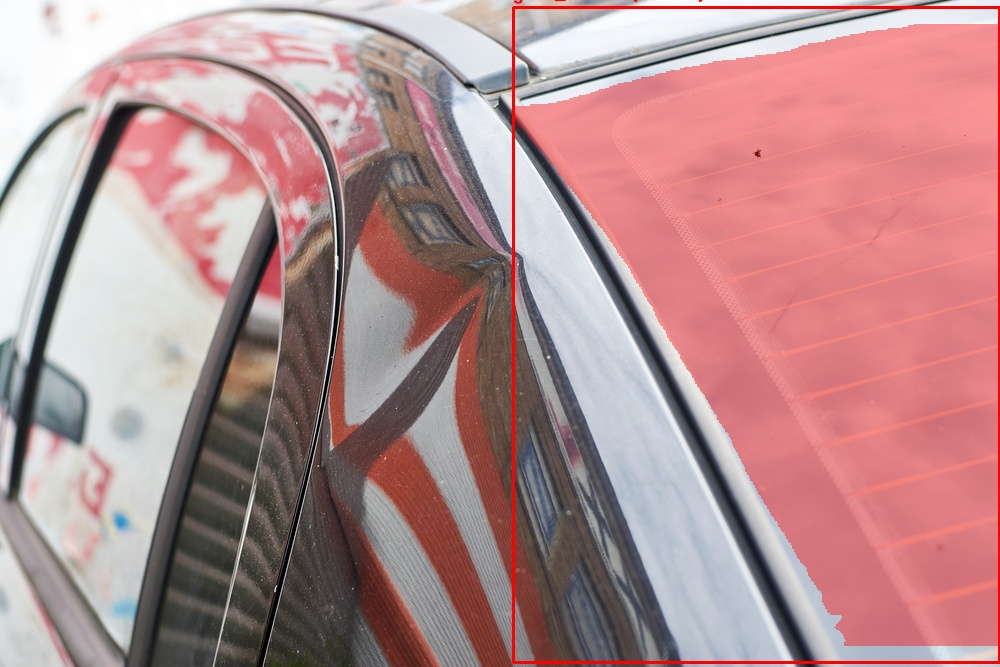

In [ ]:
import glob
import random
from IPython.display import Image as IPImage, display

NUM_DATASET_SAMPLES = 5  # <<< how many dataset images to run

assert "YOLO_DATASET_DIR" in dir(), (
    "YOLO_DATASET_DIR isn't defined -- run Appendix A2 (config) through A5 (conversion) "
    "first to download and convert the CarDD dataset."
)

for split in ["test", "val", "train"]:
    candidate_images = glob.glob(f"{YOLO_DATASET_DIR}/images/{split}/*.jpg") + \
                        glob.glob(f"{YOLO_DATASET_DIR}/images/{split}/*.png")
    if candidate_images:
        print(f"Using the '{split}' split ({len(candidate_images)} images available)")
        break
else:
    raise FileNotFoundError(
        "No images found under YOLO_DATASET_DIR/images/{test,val,train} -- make sure "
        "Appendix A5 (conversion) actually ran successfully."
    )

sample_images = random.sample(candidate_images, min(NUM_DATASET_SAMPLES, len(candidate_images)))

for image_path in sample_images:
    print(f"\n{'=' * 50}\n{image_path}\n{'=' * 50}")

    report = run_pipeline(image_path)  # <-- YOLO detect+seg only, no VLM/judge calls

    print("--- Raw CV detections ---")
    print(json.dumps(report["findings"], indent=2))

    display(IPImage(filename=report["annotated_image"]))

### 6c. On uploaded images (test with your own photos)

Upload one or more images from your device and run the full pipeline on them.


In [ ]:
from google.colab import files

uploaded = files.upload()  # a file picker will pop up -- select your images


In [ ]:
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display

def ensure_jpg(filename):
    """cv2 can be unreliable with .webp, so convert to .jpg first if needed."""
    if not filename.lower().endswith(".webp"):
        return filename
    jpg_path = os.path.splitext(filename)[0] + ".jpg"
    PILImage.open(filename).convert("RGB").save(jpg_path)
    return jpg_path


for filename in uploaded:
    image_path = ensure_jpg(filename)
    print(f"\n{'=' * 50}\n{image_path}\n{'=' * 50}")

    report = run_pipeline(image_path)  # <-- YOLO detect+seg only, no VLM/judge calls

    print("--- Raw CV detections ---")
    print(json.dumps(report["findings"], indent=2))

    display(IPImage(filename=report["annotated_image"]))

---
## Appendix — Retrain from scratch (optional)

Only needed if you want to retrain on more data / longer / a bigger model.
**Skip this whole section for normal use** — the weights are already backed up on
Drive and loaded by Section 3. This reuses the dataset already downloaded and
converted in Section 6b above, so run 6b at least once before this section.


### A1. Train YOLO26s-seg


In [ ]:
from ultralytics import YOLO

# Load YOUR trained weights instead of starting from the generic pretrained checkpoint
yolo_model = YOLO("/content/drive/MyDrive/car_damage_backup/yolo 8 25 epoch/best.pt")

yolo_model.train(
    data=f"{YOLO_DATASET_DIR}/data.yaml",
    epochs=EPOCHS,       # additional epochs to train, e.g. 75-100 more on top
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project="car_damage",
    name="yolov8n_seg_continued",
)

metrics = yolo_model.val()
print("Box mAP50-95:", metrics.box.map, "| Seg mAP50-95:", metrics.seg.map)

Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/car_damage_backup/yolo 8 25 epoch/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

### A2. Back the trained weights up to Drive

Do this before the Colab runtime recycles and the weights are lost.


In [ ]:
candidates = glob.glob("runs/segment/**/best.pt", recursive=True)
assert candidates, "No best.pt found under runs/segment/ -- did the training cell finish successfully?"
trained_weights_path = max(candidates, key=os.path.getmtime)
print(f"Found: {trained_weights_path}")

drive.mount('/content/drive')  # safe to re-call if already mounted

backup_dir = "/content/drive/MyDrive/car_damage_backup/yolo_continued_25epoch"
os.makedirs(backup_dir, exist_ok=True)

shutil.copy(trained_weights_path, os.path.join(backup_dir, "best.pt"))
print(f"Backed up to {backup_dir}/best.pt")
print("Update TRAINED_WEIGHTS_PATH in Section 2 to this path if you want to use this model going forward.")

Found: runs/segment/car_damage/yolov8n_seg_continued/weights/best.pt
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backed up to /content/drive/MyDrive/car_damage_backup/yolo_continued_25epoch/best.pt
Update TRAINED_WEIGHTS_PATH in Section 2 to this path if you want to use this model going forward.


### A3. Validation metrics on the test set (compare against the CarDD paper)


In [ ]:
# Validate on the same split the CarDD paper reports (test, 374 images) if it was
# converted in A5; otherwise fall back to val and say so explicitly.
eval_split = "test" if num_test > 0 else "val"
print(f"Evaluating on the '{eval_split}' split ({'matches' if eval_split == 'test' else 'does NOT exactly match'} the paper's protocol)\n")

metrics = yolo.val(data=f"{YOLO_DATASET_DIR}/data.yaml", split=eval_split)

print("=== Overall metrics (yours) ===")
print(f"{'Metric':12s} {'Box AP':>8s} {'Mask AP':>8s}")
print(f"{'AP50-95':12s} {metrics.box.map:8.3f} {metrics.seg.map:8.3f}")
print(f"{'AP50':12s} {metrics.box.map50:8.3f} {metrics.seg.map50:8.3f}")
print(f"{'Precision':12s} {metrics.box.mp:8.3f} {metrics.seg.mp:8.3f}")
print(f"{'Recall':12s} {metrics.box.mr:8.3f} {metrics.seg.mr:8.3f}")

# Reference numbers from the CarDD paper (Table IV), DCN+ with ResNet-101 -- the paper's
# best-performing model, evaluated on their official test set (374 images).
PAPER_DCNPLUS_OVERALL = {
    "AP50-95": {"box": 60.6, "mask": 57.0},
    "AP50":    {"box": 78.8, "mask": 77.7},
}

print("\n=== Paper reference: DCN+ (ResNet-101), Table IV ===")
print(f"{'Metric':12s} {'Box AP':>8s} {'Mask AP':>8s}")
for metric_name, values in PAPER_DCNPLUS_OVERALL.items():
    print(f"{metric_name:12s} {values['box']:8.1f} {values['mask']:8.1f}")

# Per-class AP50 from the paper (Table V), DCN+ with ResNet-101 -- mask AP / box AP
PAPER_DCNPLUS_PER_CLASS = {
    "dent":          {"mask": 40.5, "box": 42.2},
    "scratch":       {"mask": 34.3, "box": 42.3},
    "crack":         {"mask": 16.6, "box": 29.6},
    "glass_shatter": {"mask": 89.6, "box": 90.1},
    "lamp_broken":   {"mask": 70.8, "box": 69.5},
    "tire_flat":     {"mask": 90.0, "box": 90.2},
}

print("\n=== Per-class AP50 -- yours vs. paper's DCN+ ===")
print(f"{'Class':15s} {'Your Box':>9s} {'Paper Box':>10s} {'Your Mask':>10s} {'Paper Mask':>11s}")
for i, name in metrics.names.items():
    normalized_name = name.strip().lower().replace(" ", "_")
    paper_values = PAPER_DCNPLUS_PER_CLASS.get(normalized_name, {"mask": float("nan"), "box": float("nan")})
    your_box_ap50 = metrics.box.ap50[i]
    your_mask_ap50 = metrics.seg.ap50[i]
    print(f"{name:15s} {your_box_ap50:9.3f} {paper_values['box']:10.1f} "
          f"{your_mask_ap50:10.3f} {paper_values['mask']:11.1f}")

print("\nNote: DCN+ is a two-stage ResNet-101 model fine-tuned specifically for this "
      "benchmark; your YOLO model is a different, much lighter/faster single-stage "
      "architecture, so don't expect an exact match -- this is a sanity-check comparison, "
      "not an apples-to-apples benchmark rerun.")


Evaluating on the 'test' split (matches the paper's protocol)

Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 109.3±50.7 MB/s, size: 586.0 KB)
val: Scanning /content/CarDD_yolo/labels/test... 374 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 379/379 461.5it/s 0.8s
val: New cache created: /content/CarDD_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.2it/s 11.0s
                   all        379        785      0.639      0.661      0.681      0.525      0.649      0.646      0.675      0.499
                  dent        157        236      0.576      0.568      0.574      0.334      0.613      0.564      0.571       0.31
               scratch        183        307      0.542

### What to extend next

1. **Train longer / bigger.** 20 epochs on `yolo26s-seg` is enough to prove the pipeline works, not enough for real accuracy. Bump `EPOCHS` to 100–150 and try `yolo26m-seg.pt` or `yolo26l-seg.pt` once conversion + training are confirmed correct.
2. **Replace the severity heuristic with a trained classifier.** Crop each detected damage region (`image[y1:y2, x1:x2]`), label a few hundred crops minor/moderate/severe, and fine-tune a small CNN (EfficientNet-B0 is a fine choice) on them. Swap `severity_from_area_pct()` for a real classifier call.
3. **Calibrate `COST_TABLE`** against real repair-shop quotes for your target market instead of the placeholder numbers — though the VLM step already gives you a more realistic EGP figure per finding.
4. **Log VLM outputs** (Section 4) to a spreadsheet/DB over time so you can spot-check pricing drift and adjust the prompt as needed.
